In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [2]:
data_yelp = pd.read_csv('/content/25152808-yelp-labelled.txt', sep = '\t', header = None)

In [ ]:
data_yelp.head()

In [4]:
column_name = ['Review', 'Sentiment']
data_yelp.columns = column_name

In [5]:
data_yelp.shape

(1000, 2)

In [6]:
data_amazon = pd.read_csv('/content/25152800-amazon-cells-labelled.txt', sep ='\t', header = None)
data_amazon.head()

,0,1
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [10]:
data_amazon.columns = column_name

In [11]:
data_amazon.head()

,Review,Sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [12]:
data_amazon.shape

(1000, 2)

In [14]:
data_imdb = pd.read_csv('/content/25152804-imdb-labelled.txt', sep ='\t', header = None)
data_imdb.head()

,0,1
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [15]:
data_imdb.columns = column_name

In [16]:
data_imdb.head()

,Review,Sentiment
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [18]:
data_imdb.shape

(748, 2)

In [21]:
# Append all data in a single dataframe

data = pd.concat([data_yelp, data_amazon, data_imdb], ignore_index=True)


In [23]:
data.shape

(2748, 2)

In [24]:
# Check distribution of sentiments

data.Sentiment.value_counts()

Sentiment
1    1386
0    1362
Name: count, dtype: int64

In [26]:
data.isna().sum()

Review       0
Sentiment    0
dtype: int64

In [27]:
X = data.Review
y = data.Sentiment

Data Cleaning

In [28]:
import string

In [29]:
punct = string.punctuation

In [30]:
punct

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [31]:
from spacy.lang.en.stop_words import STOP_WORDS

In [32]:
stopwords = list(STOP_WORDS)

In [35]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import string

# Load spaCy English language model
nlp = spacy.load('en_core_web_sm')

# Define function for text data cleaning
def text_data_cleaning(sentence):
    # Process the input sentence using spaCy
    doc = nlp(sentence)

    # Initialize lists for tokens and cleaned tokens
    tokens = []
    cleaned_tokens = []

    # Iterate over each token in the processed document
    for token in doc:
        if token.lemma_ != "-PRON-":
            # Get the lemma (base form) of the token and convert to lowercase
            temp = token.lemma_.lower().strip()
        else:
            # Handle pronouns separately
            temp = token.lower_

        # Append token to list of tokens
        tokens.append(temp)

    # Define set of stopwords and punctuation
    stopwords = STOP_WORDS
    punctuations = string.punctuation

    # Iterate over each token and filter out stopwords and punctuation
    for token in tokens:
        if token not in stopwords and token not in punctuations:
            cleaned_tokens.append(token)

    return cleaned_tokens

# Example usage of the text_data_cleaning function
cleaned_text = text_data_cleaning("Hello all, It's a beautiful day outside there")
print(cleaned_text)


['hello', 'beautiful', 'day', 'outside']


Vectorization Feature Engineering

In [36]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

In [37]:
tfidf = TfidfVectorizer(tokenizer = text_data_cleaning)

In [52]:
from sklearn.naive_bayes import MultinomialNB


classifier = MultinomialNB()

Train the model

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [54]:
X_train.shape, X_test.shape

((2198,), (550,))

In [55]:
clf = Pipeline([('tfidf', tfidf), ('clf', classifier)])
clf

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(tokenizer=<function text_data_cleaning at 0x784a0d6265f0>)),
                ('clf', MultinomialNB())])

In [56]:
clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(tokenizer=<function text_data_cleaning at 0x784a0d6265f0>)),
                ('clf', MultinomialNB())])

Predict the test set results

In [57]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [58]:
y_pred = clf.predict(X_test)

In [59]:
confusion_matrix(y_test, y_pred)

array([[213,  72],
       [ 49, 216]])

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       285
           1       0.75      0.82      0.78       265

    accuracy                           0.78       550
   macro avg       0.78      0.78      0.78       550
weighted avg       0.78      0.78      0.78       550



In [71]:
accuracy_score(y_test, y_pred) * 100

78.0

In [62]:
clf.predict(["Wow, I am learning Natural Language Processing in fun fashion!"])

array([1])

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extr

Classifier: MultinomialNB
Accuracy: 0.79
Precision: 0.79
Recall: 0.79
F1 Score: 0.79
AUC Score: 0.98



/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extr

Classifier: LogisticRegression
Accuracy: 0.79
Precision: 0.79
Recall: 0.79
F1 Score: 0.79
AUC Score: 0.98



/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extr

Classifier: SVM
Accuracy: 0.79
Precision: 0.79
Recall: 0.79
F1 Score: 0.79
AUC Score: 0.99

Best Model (Highest Accuracy): SVC(probability=True)
Best Accuracy: 0.79


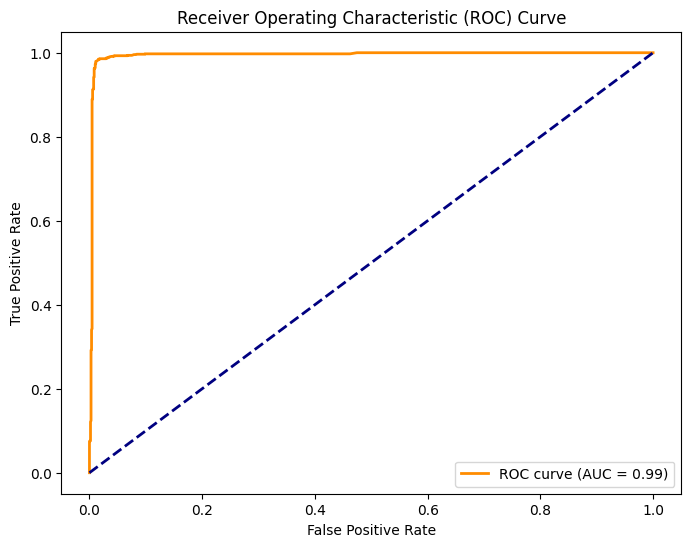

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define TF-IDF vectorizer with custom tokenizer
tfidf = TfidfVectorizer(tokenizer=text_data_cleaning)

# Define classifiers
classifiers = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(),
    'SVM': SVC(probability=True)  # Set probability=True for SVC to calculate ROC/AUC
}

# Initialize variables to track best model and its performance
best_model = None
best_accuracy = 0.0

# Iterate over each classifier
for clf_name, clf in classifiers.items():
    # Create a pipeline with TF-IDF vectorizer and classifier
    pipeline = Pipeline([
        ('tfidf', tfidf),
        ('clf', clf)
    ])

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Use cross-validation to predict on training data
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred, average='macro')
    recall = recall_score(y_train, y_pred, average='macro')
    f1 = f1_score(y_train, y_pred, average='macro')

    # Calculate ROC curve and AUC score
    y_prob = pipeline.predict_proba(X_train)
    fpr, tpr, thresholds = roc_curve(y_train, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)

    # Print evaluation metrics for each classifier
    print(f"Classifier: {clf_name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"AUC Score: {roc_auc:.2f}")
    print()

    # Update best model if current model has higher accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Display the best model with the highest accuracy
print(f"Best Model (Highest Accuracy): {best_model.named_steps['clf']}")
print(f"Best Accuracy: {best_accuracy:.2f}")

# Plot ROC curve for the best model
y_prob_best = best_model.predict_proba(X_train)
fpr_best, tpr_best, _ = roc_curve(y_train, y_prob_best[:, 1], pos_label=1)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
